# ChainConsumer vs getdist
--------------------------------

In [16]:
from pathlib import Path
from typing import Dict, List, Tuple

import importlib

import getdist.plots as gdplots
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from chainconsumer import Chain, ChainConsumer, PlotConfig
from chainconsumer.plotting import plot_contour
from getdist import MCSamples
from matplotlib.lines import Line2D

import corner_utils as corners
import src.analysis.plots as plots
import src.statistics.corrfiles as cf

importlib.reload(corners)

PAPER_FIGURES_ROOT = Path(
    "/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/paper/figures/"
)
PAPER_FIGURES_ROOT.mkdir(parents=True, exist_ok=True)
SUMMARY_ROOT = Path("summaries")
SUMMARY_ROOT.mkdir(exist_ok=True)

pm = plots.PlotManager(root=PAPER_FIGURES_ROOT, overwrite=True)
CHAIN_ROOT = cf.get_base_dir() / "cosmic_shear" / "chains"
default_file = "hsc-y3-shear.txt"
plots.plot_settingbfegesggrsgr se

In [36]:
chain_file = CHAIN_ROOT / "out-corrected-nz-real-0.3-3-fiducial" / default_file
base_burn = 0.15
chain_label = "0.3-3 fiducial"

params = [
    "cosmological_parameters--omega_m",
    "COSMOLOGICAL_PARAMETERS--S_8",
    "COSMOLOGICAL_PARAMETERS--SIGMA_8",
    "wl_photoz_errors--bias_3",
    "wl_photoz_errors--bias_4",
]
param_labels = [
    r"\Omega_m",
    r"S_8",
    r"\sigma_8",
    r"\Delta z_3",
    r"\Delta z_4",
]
display_labels = [
    r"$\Omega_m$",
    r"$S_8$",
    r"$\sigma_8$",
    r"$\Delta z_3$",
    r"$\Delta z_4$",
]
cc_columns = ["Omega_m", "S_8", "sigma_8", "Delta_z_3", "Delta_z_4"]

label_map = dict(zip(params, display_labels))
cc_param_map = dict(zip(params, cc_columns))
cc_label_map = dict(zip(cc_columns, display_labels))


def format_interval(center: float, lower: float, upper: float) -> str:
    """Format a central value with asymmetric 68 percent errors."""
    return f"{center:.4f} (+{upper - center:.4f}, -{center - lower:.4f})"


def extract_contours_from_axis(axis: plt.Axes) -> List[List[np.ndarray]]:
    """Collect contour path vertices from a matplotlib axis."""
    contour_sets: List[List[np.ndarray]] = []
    for collection in axis.collections:
        paths: List[np.ndarray] = []
        for path in collection.get_paths():
            vertices = np.asarray(path.vertices, dtype=float)
            if vertices.size:
                paths.append(vertices)
        if paths:
            contour_sets.append(paths)
    return contour_sets


def extract_getdist_density(samples: MCSamples, param: str) -> Tuple[np.ndarray, np.ndarray]:
    """Return the getdist 1D density curve for one parameter."""
    density = samples.get1DDensity(param)
    x = np.asarray(density.x, dtype=float)
    y = np.asarray(density.P, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    return x[mask], y[mask]

In [37]:
df_raw, header, prior_rescale = corners.load_and_process_data(chain_file)
assert np.allclose(prior_rescale, 1.0), "The 0.3-3 chain should not need prior rescaling."
assert all(param in df_raw.columns for param in params), "A requested parameter is missing."

getdist_samples, processed_df, _ = corners.make_mc_sample(
    df_raw,
    params,
    param_labels,
    prior_rescale,
    chain_label,
    burn=base_burn,
    use_log_weight=True,
)

weights = processed_df["effw"].to_numpy(dtype=float)
weights = np.where(weights > 0, weights, 1e-300)
processed_df["effw"] = weights
assert np.all(np.isfinite(processed_df[params].to_numpy())), "Non-finite samples found."
assert np.all(np.isfinite(weights)), "Non-finite weights found."
assert np.all(weights > 0), "Weights must be strictly positive after cleaning."

cc_df = processed_df[params].copy()
cc_df["effw"] = weights
cc_df["post_reweighted"] = processed_df["post-reweighted"].to_numpy()
cc_df = cc_df.rename(columns=cc_param_map)

cc_df.head()

Removed no burn in


,Omega_m,S_8,sigma_8,Delta_z_3,Delta_z_4,effw,post_reweighted
0,0.212723,0.817477,0.970798,-0.012986,-0.005430,0.000189,-44.392801
1,0.253979,0.792602,0.861424,0.011269,0.015389,0.000284,-39.641005
2,0.198140,0.804451,0.989862,0.013617,0.005644,0.000276,-40.943458
3,0.272331,0.814414,0.854786,0.001214,0.007754,0.000284,-38.722851
4,0.275903,0.832802,0.868409,-0.005734,-0.010715,0.000274,-42.072702


In [44]:
plot_config = PlotConfig(
    max_ticks=5,
    plot_hists=False,
    serif=False,
    usetex=False,
    diagonal_tick_labels=True,
    label_font_size=14,
    tick_font_size=12,
    spacing=1.25,
    contour_label_font_size=12,
    show_legend=False,
    summarise=False,
)

consumer = ChainConsumer()
consumer.set_plot_config(plot_config=plot_config)
cc_chain = Chain(
    samples=cc_df,
    name=chain_label,
    weight_column="effw",
    color="#dd8452",
    shade=False,
    linewidth=1.8,
    kde=1,
    grid=True,
)
consumer.add_chain(cc_chain)

# ChainConsumer's 2D contour helper becomes pathological for this chain when
# grid=True because it bins on every unique sample value before running KDE.
cc_contour_chain = cc_chain.model_copy(update={"grid": False, "kde": 1})

PDF_PANEL_WIDTH = 4.5
PDF_PANEL_HEIGHT = 3.8
PDF_PLOT_YMAX = 1.05


def normalize_density(
    x: np.ndarray,
    y: np.ndarray,
) -> Tuple[np.ndarray, np.ndarray]:
    """Normalize a 1D density to unit area after sorting and cleaning."""
    mask = np.isfinite(x) & np.isfinite(y)
    x = np.asarray(x[mask], dtype=float)
    y = np.asarray(y[mask], dtype=float)
    order = np.argsort(x)
    x = x[order]
    y = y[order]
    area = np.trapezoid(y, x)
    assert area > 0, "Density normalization requires a positive area."
    return x, y / area


def scale_density_for_plot(y: np.ndarray) -> np.ndarray:
    """Rescale a normalized density to unit peak for direct shape comparison."""
    ymax = np.nanmax(y)
    assert ymax > 0, "Density normalization requires a positive maximum."
    return y / ymax


def add_mode_interval(
    axis: plt.Axes,
    summary: Dict[str, object],
    color: str,
    alpha: float = 0.12,
) -> None:
    """Draw the 34 percent interval around the posterior mode."""
    lower, upper = summary["ci68"]
    axis.axvspan(lower, upper, color=color, alpha=alpha, lw=0)


def summarize_density(
    x: np.ndarray,
    y: np.ndarray,
    map_value: float,
) -> Dict[str, object]:
    """Recover mode, mean, and asymmetric intervals using the corners.ipynb recipe."""
    x, pdf = normalize_density(x, y)
    posterior_mode = x[np.argmax(pdf)]
    posterior_mean = np.trapezoid(pdf * x, x)
    dx = np.mean(np.diff(x))
    cdf = np.cumsum(pdf * dx)
    cdf /= cdf[-1]
    ci68 = corners.asymmetric_confidence_interval(x, pdf, cdf, 0.34)
    ci95 = corners.asymmetric_confidence_interval(x, pdf, cdf, 0.475)
    return {
        "map": map_value,
        "mode": posterior_mode,
        "mean": posterior_mean,
        "ci68": ci68,
        "ci95": ci95,
        "x": x,
        "pdf": pdf,
    }


def extract_chainconsumer_density(
    current_consumer: ChainConsumer,
    column: str,
) -> Tuple[np.ndarray, np.ndarray]:
    """Extract the main 1D density curve drawn by ChainConsumer."""
    fig = current_consumer.plotter.plot_distributions(
        columns=[column],
        col_wrap=1,
        figsize=(4, 3),
    )
    try:
        axes_with_lines = [axis for axis in fig.axes if axis.lines]
        assert axes_with_lines, f"No ChainConsumer density lines found for {column}."
        axis = axes_with_lines[0]
        line = max(axis.lines, key=lambda artist: len(np.atleast_1d(artist.get_xdata())))
        x = np.asarray(line.get_xdata(), dtype=float)
        y = np.asarray(line.get_ydata(), dtype=float)
        return normalize_density(x, y)
    finally:
        plt.close(fig)


def extract_getdist_contours(
    samples: MCSamples,
    x_param: str,
    y_param: str,
) -> Tuple[List[List[np.ndarray]], Tuple[float, float], Tuple[float, float]]:
    """Extract getdist contour paths for one parameter pair."""
    plotter = gdplots.get_single_plotter(width_inch=5, ratio=1)
    plotter.plot_2d(samples, x_param, y_param, filled=False, colors=["#4c72b0"])
    fig = plotter.fig
    try:
        assert fig is not None and fig.axes, "getdist did not create a contour axis."
        axis = fig.axes[0]
        contour_sets = extract_contours_from_axis(axis)
        return contour_sets, axis.get_xlim(), axis.get_ylim()
    finally:
        plt.close(fig)


def extract_getdist_density(samples: MCSamples, param: str) -> Tuple[np.ndarray, np.ndarray]:
    """Return the getdist 1D density curve for one parameter."""
    density = samples.get1DDensity(param)
    return normalize_density(np.asarray(density.x, dtype=float), np.asarray(density.P, dtype=float))


def extract_chainconsumer_contours(
    current_chain: Chain,
    x_param: str,
    y_param: str,
) -> Tuple[List[List[np.ndarray]], Tuple[float, float], Tuple[float, float]]:
    """Extract ChainConsumer contour paths for one parameter pair."""
    contour_chain = current_chain
    if current_chain.grid and current_chain.kde:
        contour_chain = current_chain.model_copy(update={"grid": False})

    fig, axis = plt.subplots(figsize=(5, 5))
    try:
        plot_contour(axis, contour_chain, px=x_param, py=y_param)
        contour_sets = extract_contours_from_axis(axis)
        return contour_sets, axis.get_xlim(), axis.get_ylim()
    finally:
        plt.close(fig)


def get_getdist_summary(param: str) -> Dict[str, object]:
    """Compute the getdist summary used in the current notebooks."""
    map_value = processed_df.loc[processed_df["post-reweighted"].idxmax(), param]
    x, pdf = extract_getdist_density(getdist_samples, param)
    return summarize_density(x, pdf, map_value)


def get_chainconsumer_summary(param: str) -> Dict[str, object]:
    """Compute ChainConsumer summaries with the same recipe used in corners.ipynb."""
    column = cc_param_map[param]
    map_value = processed_df.loc[processed_df["post-reweighted"].idxmax(), param]
    x, pdf = extract_chainconsumer_density(consumer, column)
    return summarize_density(x, pdf, map_value)

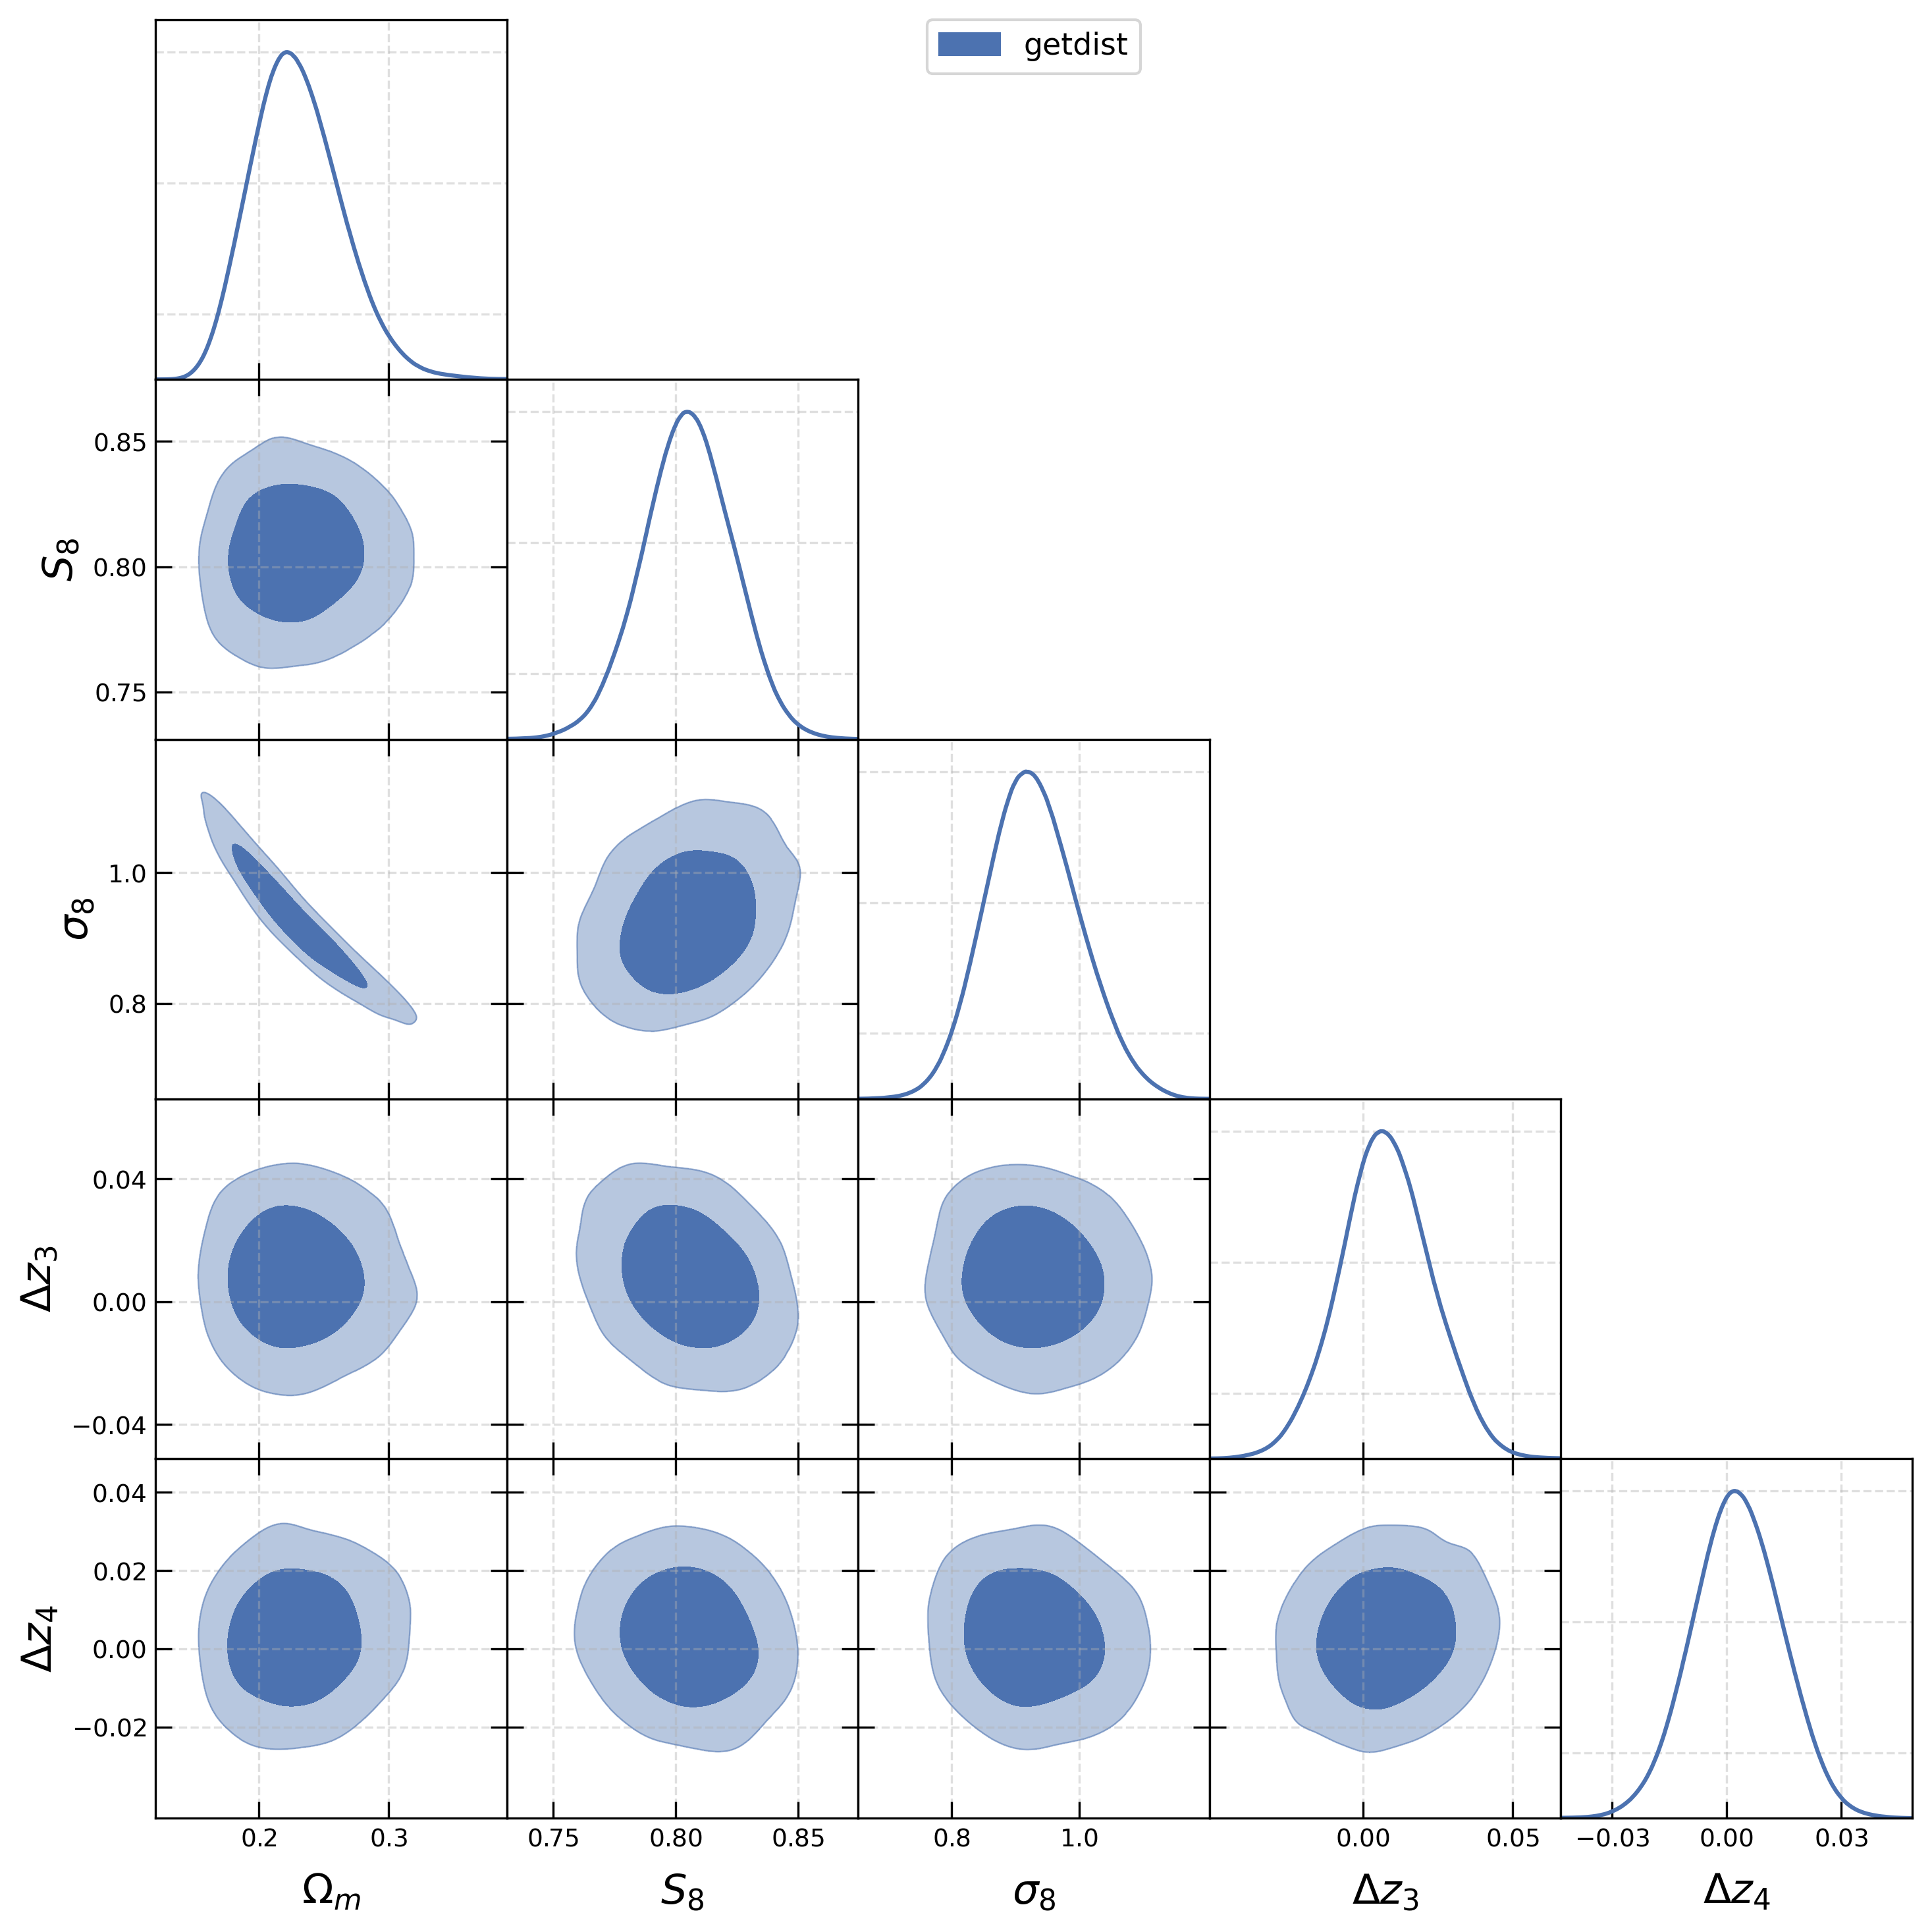

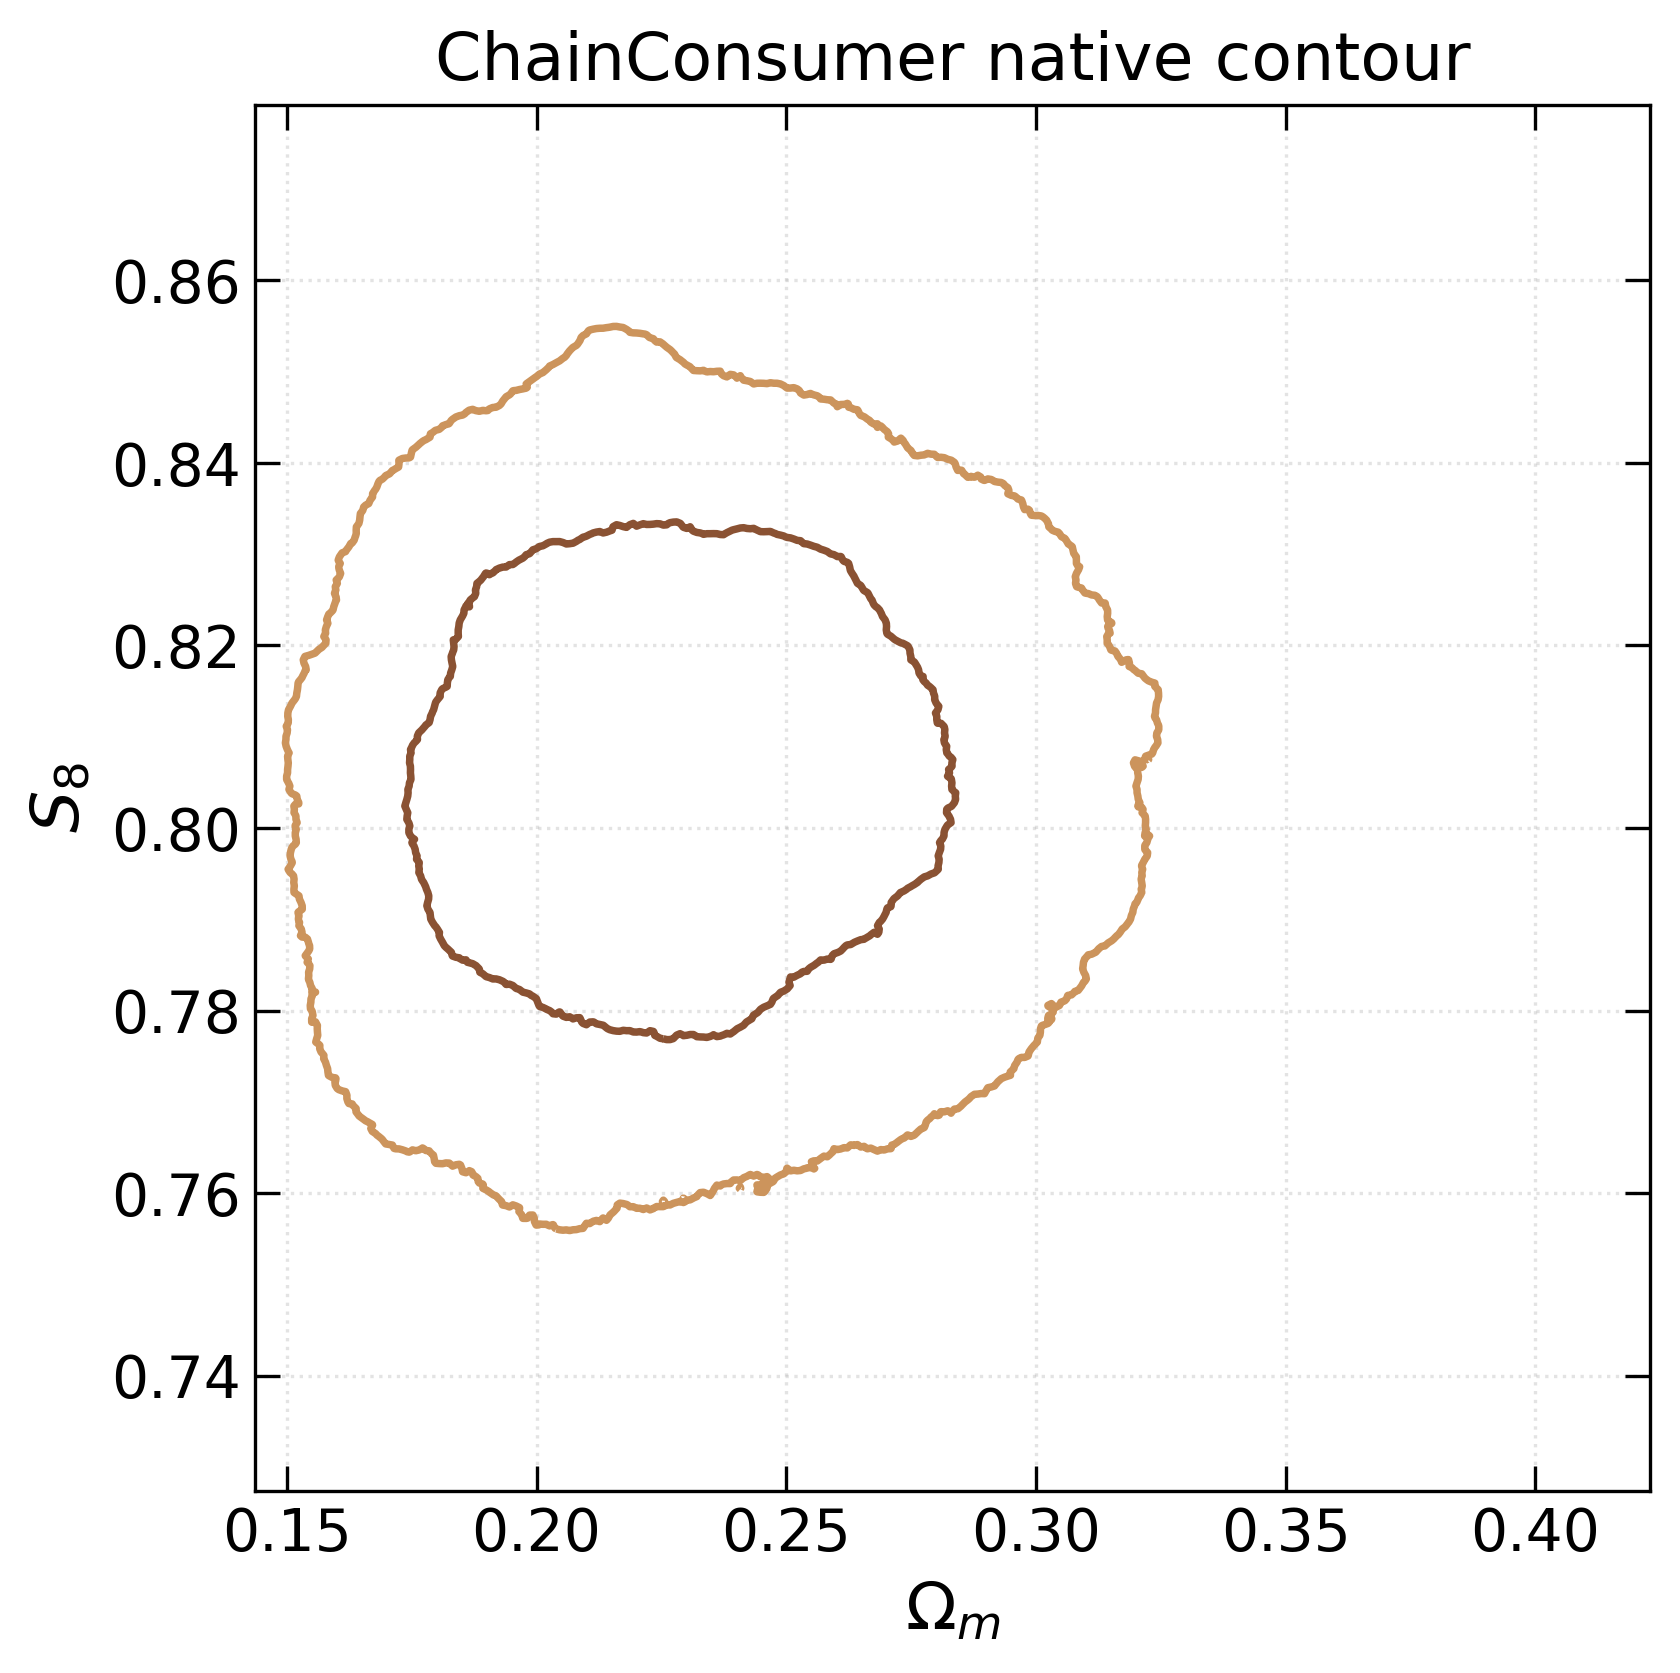

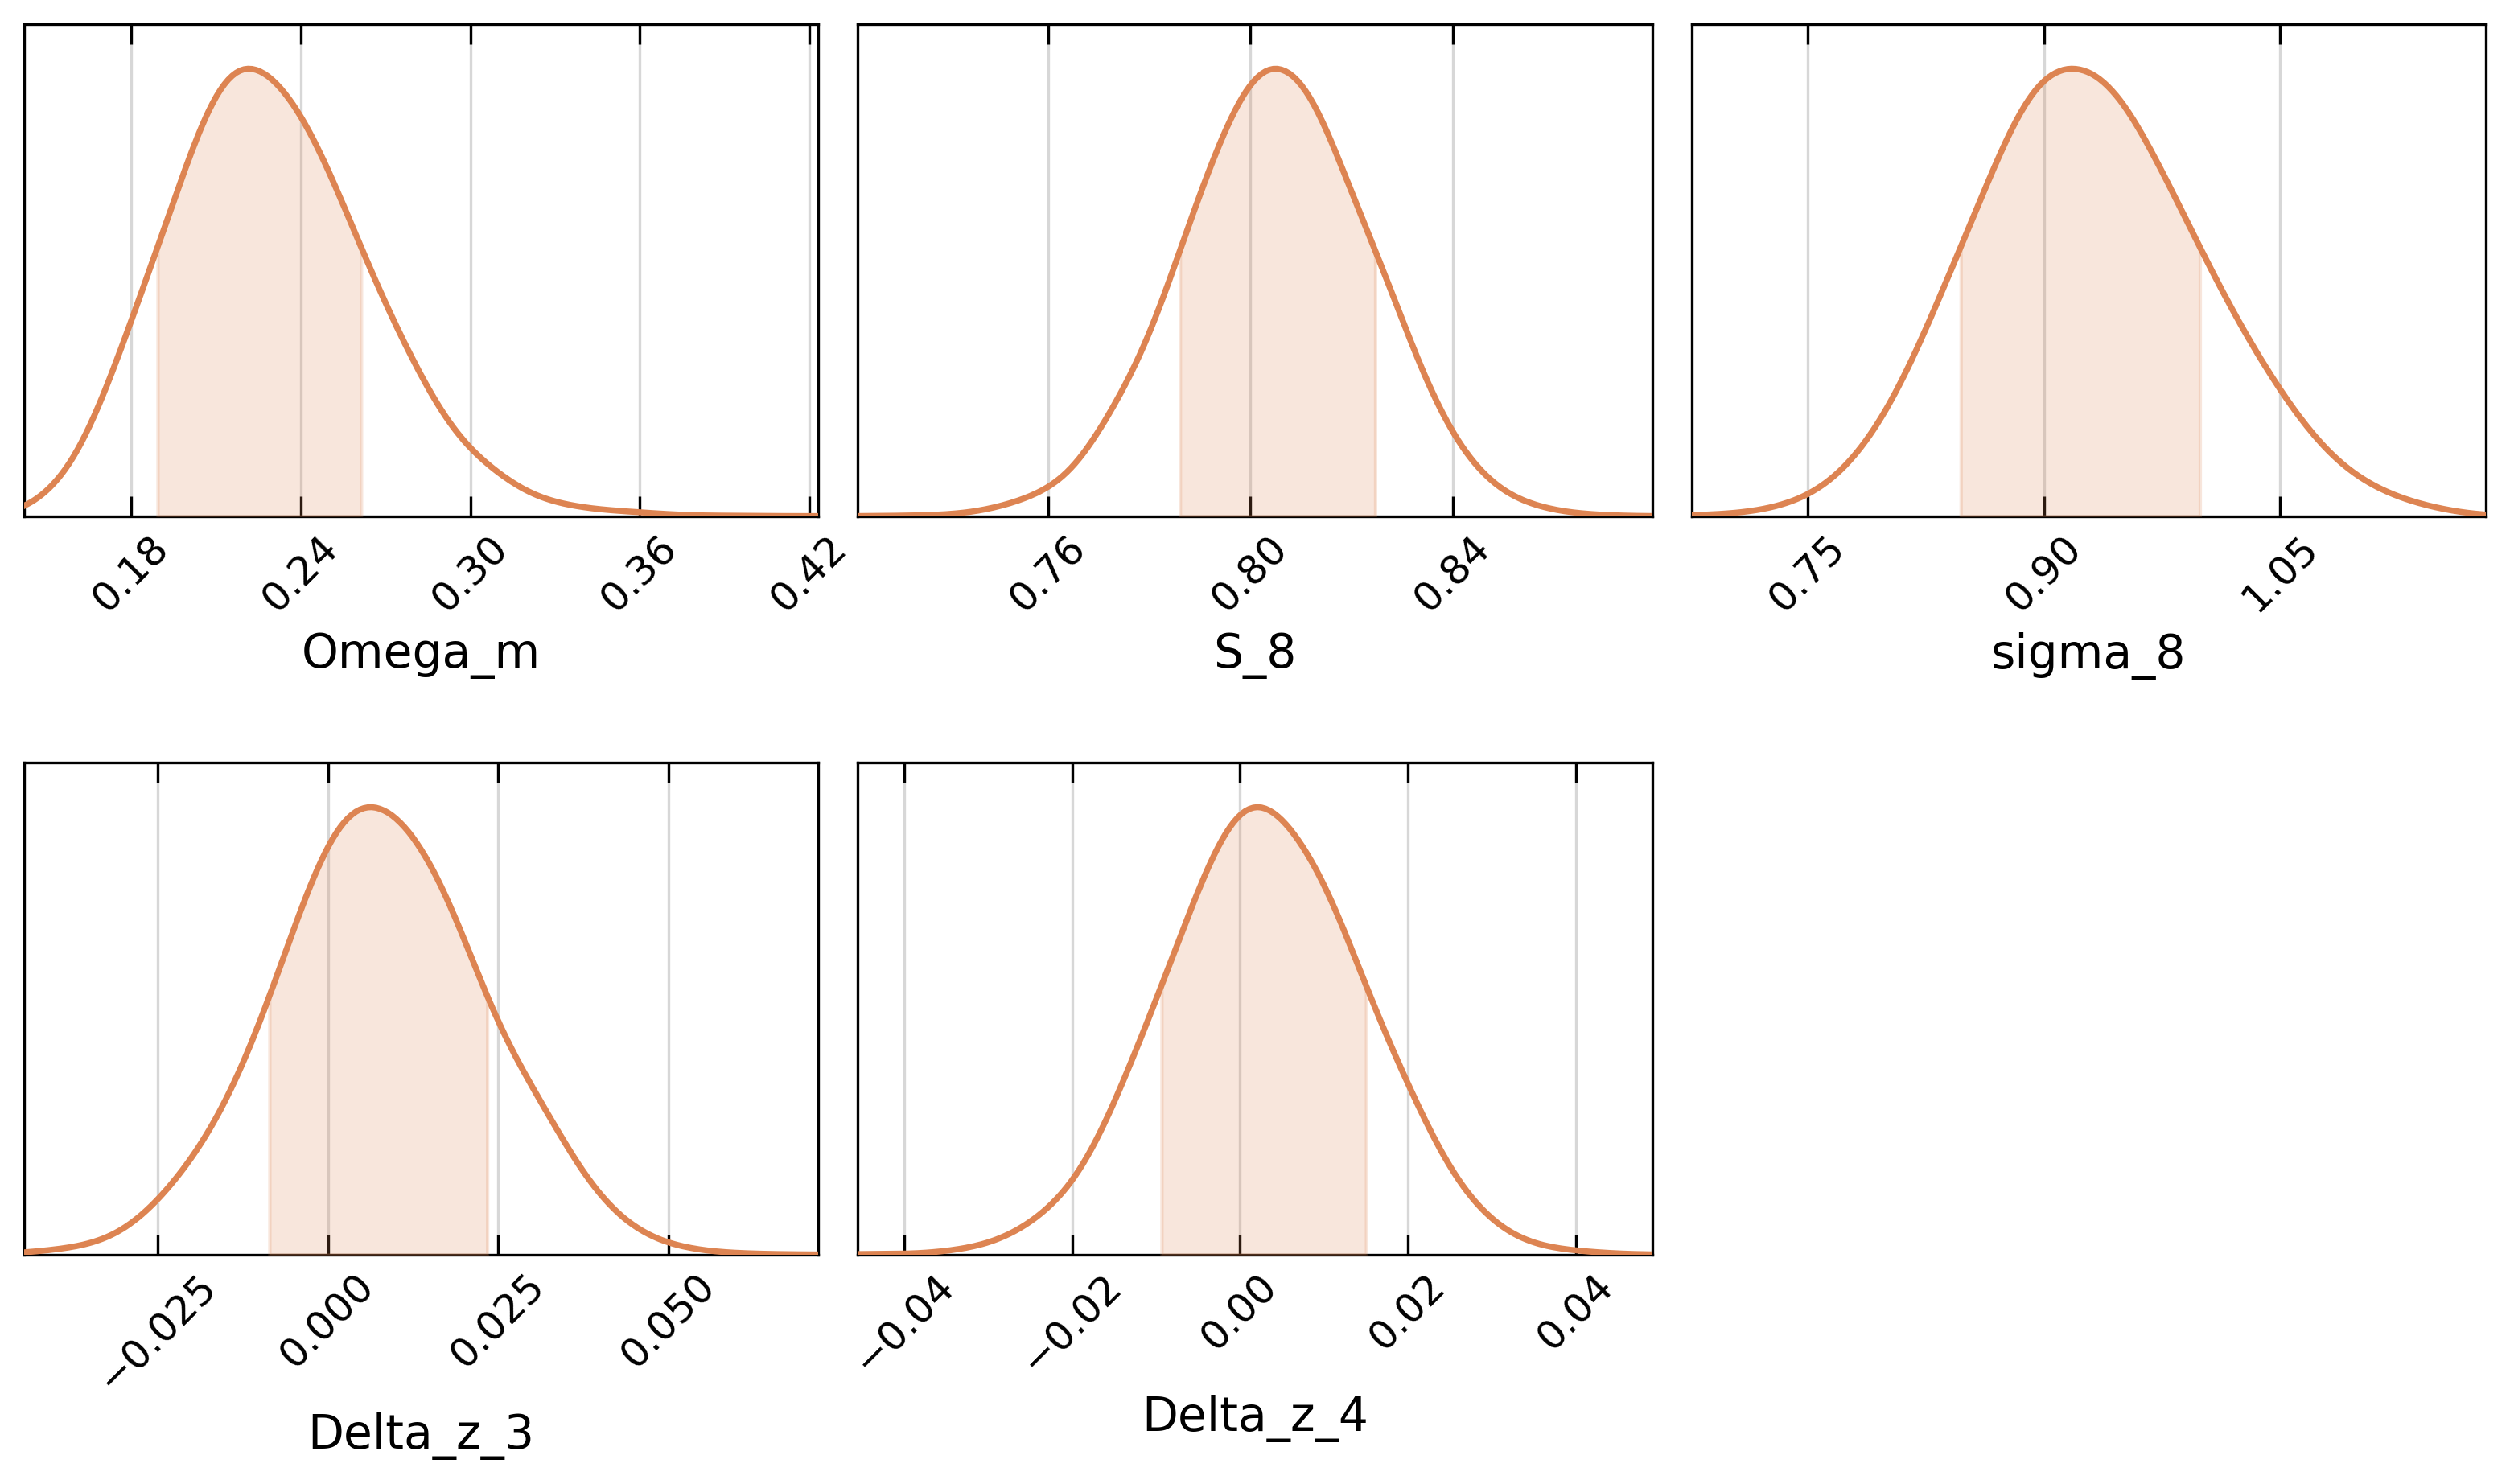

In [45]:
g = gdplots.get_subplot_plotter(rc_sizes=True)
g.settings.fontsize = 12
g.settings.axis_tick_max_labels = 4
g.settings.axes_fontsize = 12
g.settings.axes_labelsize = 18
g.settings.legend_fontsize = 14
g.settings.legend_loc = "upper right"

g.triangle_plot(
    [getdist_samples],
    params,
    filled=True,
    contour_colors=["#4c72b0"],
    line_args=[{"color": "#4c72b0", "lw": 1.5}],
    legend_labels=["getdist"],
)
for axis in g.subplots.flatten():
    if axis:
        axis.grid(True, linestyle="--", alpha=0.4)
plt.savefig(PAPER_FIGURES_ROOT / "getdist_0p3_3_triangle.png", bbox_inches="tight")
plt.show()
plt.close("all")

fig, axis = plt.subplots(figsize=(6, 6))
plot_contour(
    axis,
    cc_contour_chain,
    px=cc_param_map["cosmological_parameters--omega_m"],
    py=cc_param_map["COSMOLOGICAL_PARAMETERS--S_8"],
)
axis.set_xlabel(label_map["cosmological_parameters--omega_m"], fontsize=16)
axis.set_ylabel(label_map["COSMOLOGICAL_PARAMETERS--S_8"], fontsize=16)
axis.set_title("ChainConsumer native contour", fontsize=16)
axis.grid(True, linestyle=":", alpha=0.35)
fig.savefig(PAPER_FIGURES_ROOT / "chainconsumer_0p3_3_omega_m_s8.png", bbox_inches="tight")
plt.show()
plt.close(fig)

fig = consumer.plotter.plot_distributions(
    columns=[cc_param_map[param] for param in params],
    col_wrap=3,
    figsize=(12, 6),
)
fig.savefig(PAPER_FIGURES_ROOT / "chainconsumer_0p3_3_distributions.png", bbox_inches="tight")
plt.show()
plt.close(fig)

In [68]:
summary_rows = []
for param in params:
    getdist_summary = get_getdist_summary(param)
    chainconsumer_summary = get_chainconsumer_summary(param)
    getdist_ci68 = getdist_summary["ci68"]
    cc_ci68 = chainconsumer_summary["ci68"]

    summary_rows.append(
        {
            "parameter": label_map[param],
            "getdist_mode_68": format_interval(
                getdist_summary["mode"],
                getdist_ci68[0],
                getdist_ci68[1],
            ),
            "getdist_map": f"{getdist_summary['map']:.4f}",
            "getdist_mean": f"{getdist_summary['mean']:.4f}",
            "cc_mode_68": format_interval(
                chainconsumer_summary["mode"],
                cc_ci68[0],
                cc_ci68[1],
            ),
            "cc_map": f"{chainconsumer_summary['map']:.4f}",
            "cc_mean": f"{chainconsumer_summary['mean']:.4f}",
        }
    )

summary_df = pd.DataFrame(summary_rows)
summary_file = SUMMARY_ROOT / "chainconsumer_getdist_0p3_3_summary.txt"
with open(summary_file, "w") as stream:
    stream.write(summary_df.to_string(index=False))

print(f"Saved summary table to {summary_file}")
summary_df

Saved summary table to summaries/chainconsumer_getdist_0p3_3_summary.txt


,parameter,getdist_mode_68,getdist_map,getdist_mean,cc_mode_68,cc_map,cc_mean
0,$\Omega_m$,"0.2218 (+0.0332, -0.0356)",0.2425,0.2299,"0.2212 (+0.0343, -0.0380)",0.2425,0.2297
1,$S_8$,"0.8046 (+0.0181, -0.0186)",0.8153,0.8050,"0.8052 (+0.0192, -0.0190)",0.8153,0.8050
2,$\sigma_8$,"0.9166 (+0.0706, -0.0754)",0.9068,0.9281,"0.9172 (+0.0737, -0.0785)",0.9068,0.9281
3,$\Delta z_3$,"0.0064 (+0.0148, -0.0156)",0.0010,0.0077,"0.0064 (+0.0154, -0.0163)",0.0010,0.0077
4,$\Delta z_4$,"0.0022 (+0.0115, -0.0120)",-0.0012,0.0028,"0.0020 (+0.0118, -0.0126)",-0.0012,0.0029


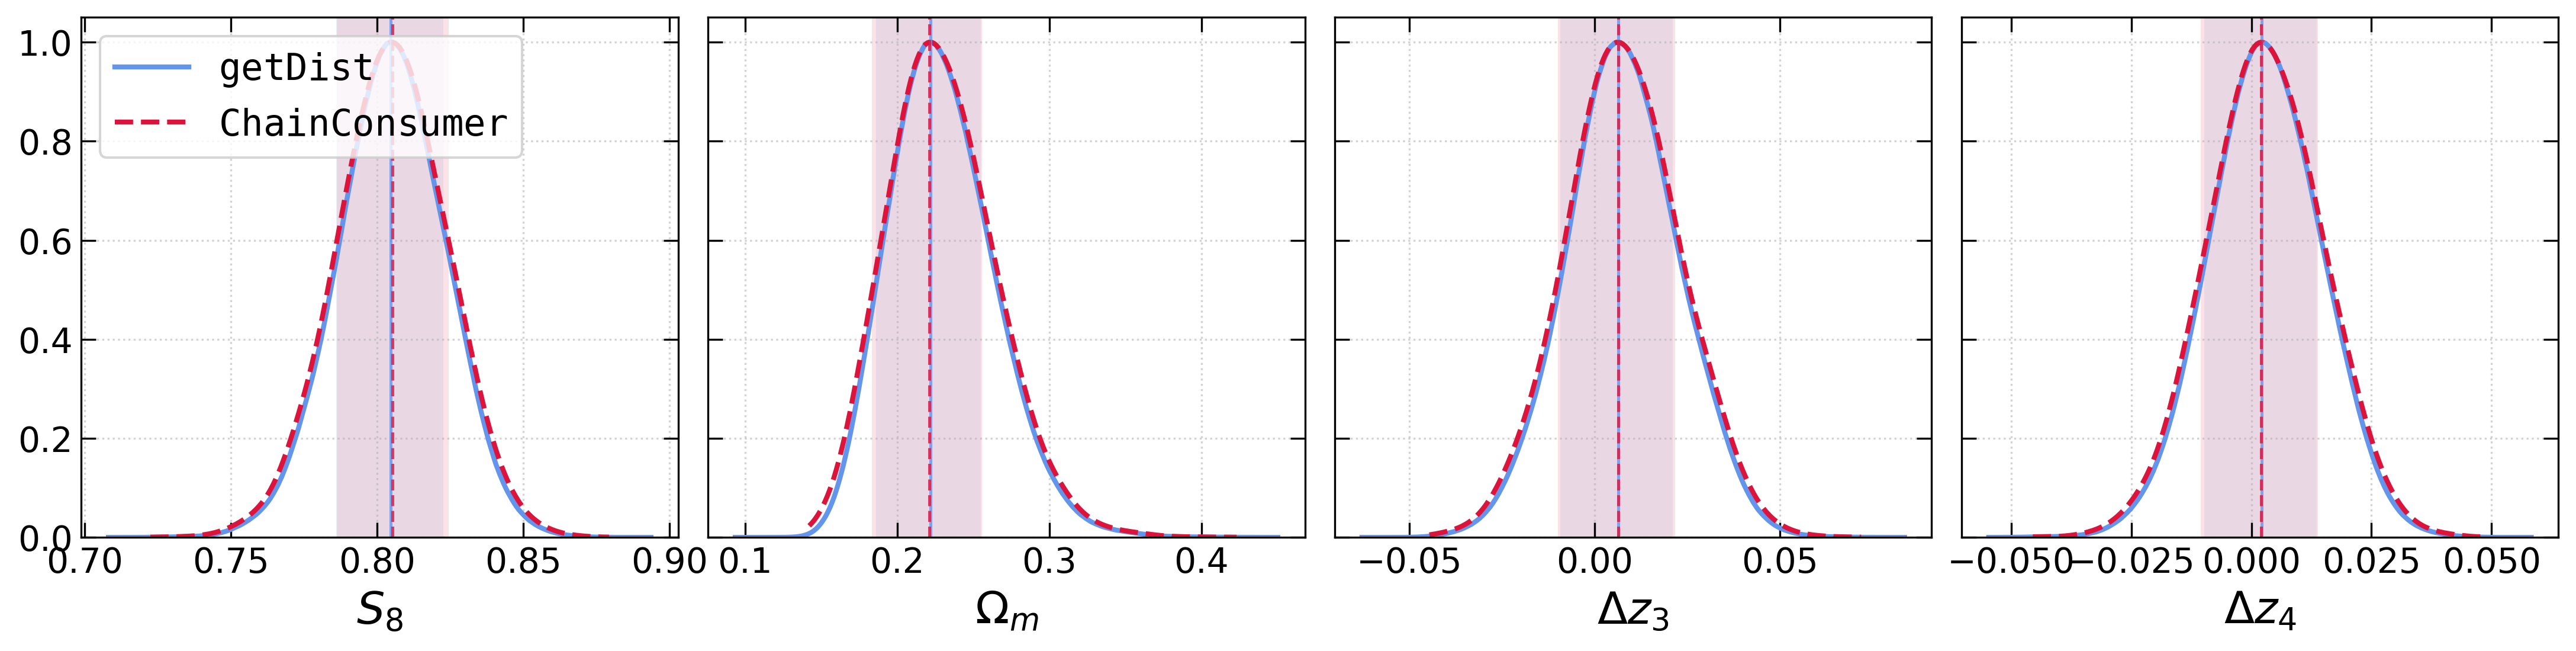

In [75]:
additional_params = [
    "COSMOLOGICAL_PARAMETERS--S_8",
    "cosmological_parameters--omega_m",
    "wl_photoz_errors--bias_3",
    "wl_photoz_errors--bias_4",
]

with pm.make_plot(
    figsize=(PDF_PANEL_WIDTH * len(additional_params), PDF_PANEL_HEIGHT),
    name="getdist_cc_comparison",
    nrows=1,
    ncols=len(additional_params),
    sharey=True,
    show=True,
    tight_layout=False,
    gridspec_kw = {"wspace": 0.05},
) as (fig, axes):
    axes = np.atleast_1d(axes)
    for indx, (axis, param) in enumerate(zip(axes, additional_params)):
        getdist_summary = get_getdist_summary(param)
        chainconsumer_summary = get_chainconsumer_summary(param)

        add_mode_interval(axis, getdist_summary, color="cornflowerblue")
        add_mode_interval(axis, chainconsumer_summary, color="crimson")

        axis.plot(
            getdist_summary["x"],
            scale_density_for_plot(getdist_summary["pdf"]),
            color="cornflowerblue",
            lw=2.0,
            label=r"$\mathtt{getDist}$",
        )
        axis.plot(
            chainconsumer_summary["x"],
            scale_density_for_plot(chainconsumer_summary["pdf"]),
            color="crimson",
            lw=2.0,
            ls="--",
            label=r"$\mathtt{ChainConsumer}$",
        )

        axis.axvline(getdist_summary["mode"], color="cornflowerblue", lw=1.2, alpha=0.8)
        axis.axvline(
            chainconsumer_summary["mode"],
            color="crimson",
            lw=1.2,
            ls="--",
            alpha=0.8,
        )

        axis.set_xlabel(label_map[param], fontsize=18)
        axis.set_ylim(0, PDF_PLOT_YMAX)
        axis.grid(True, linestyle=":", alpha=0.55)
        if indx == 0:
            axis.legend(loc="upper left", fontsize=15)

    plt.subplots_adjust(wspace=0.25)
    plt.show()

Saved smoothing scan to summaries/chainconsumer_getdist_smoothing_scan_0p3_3.txt


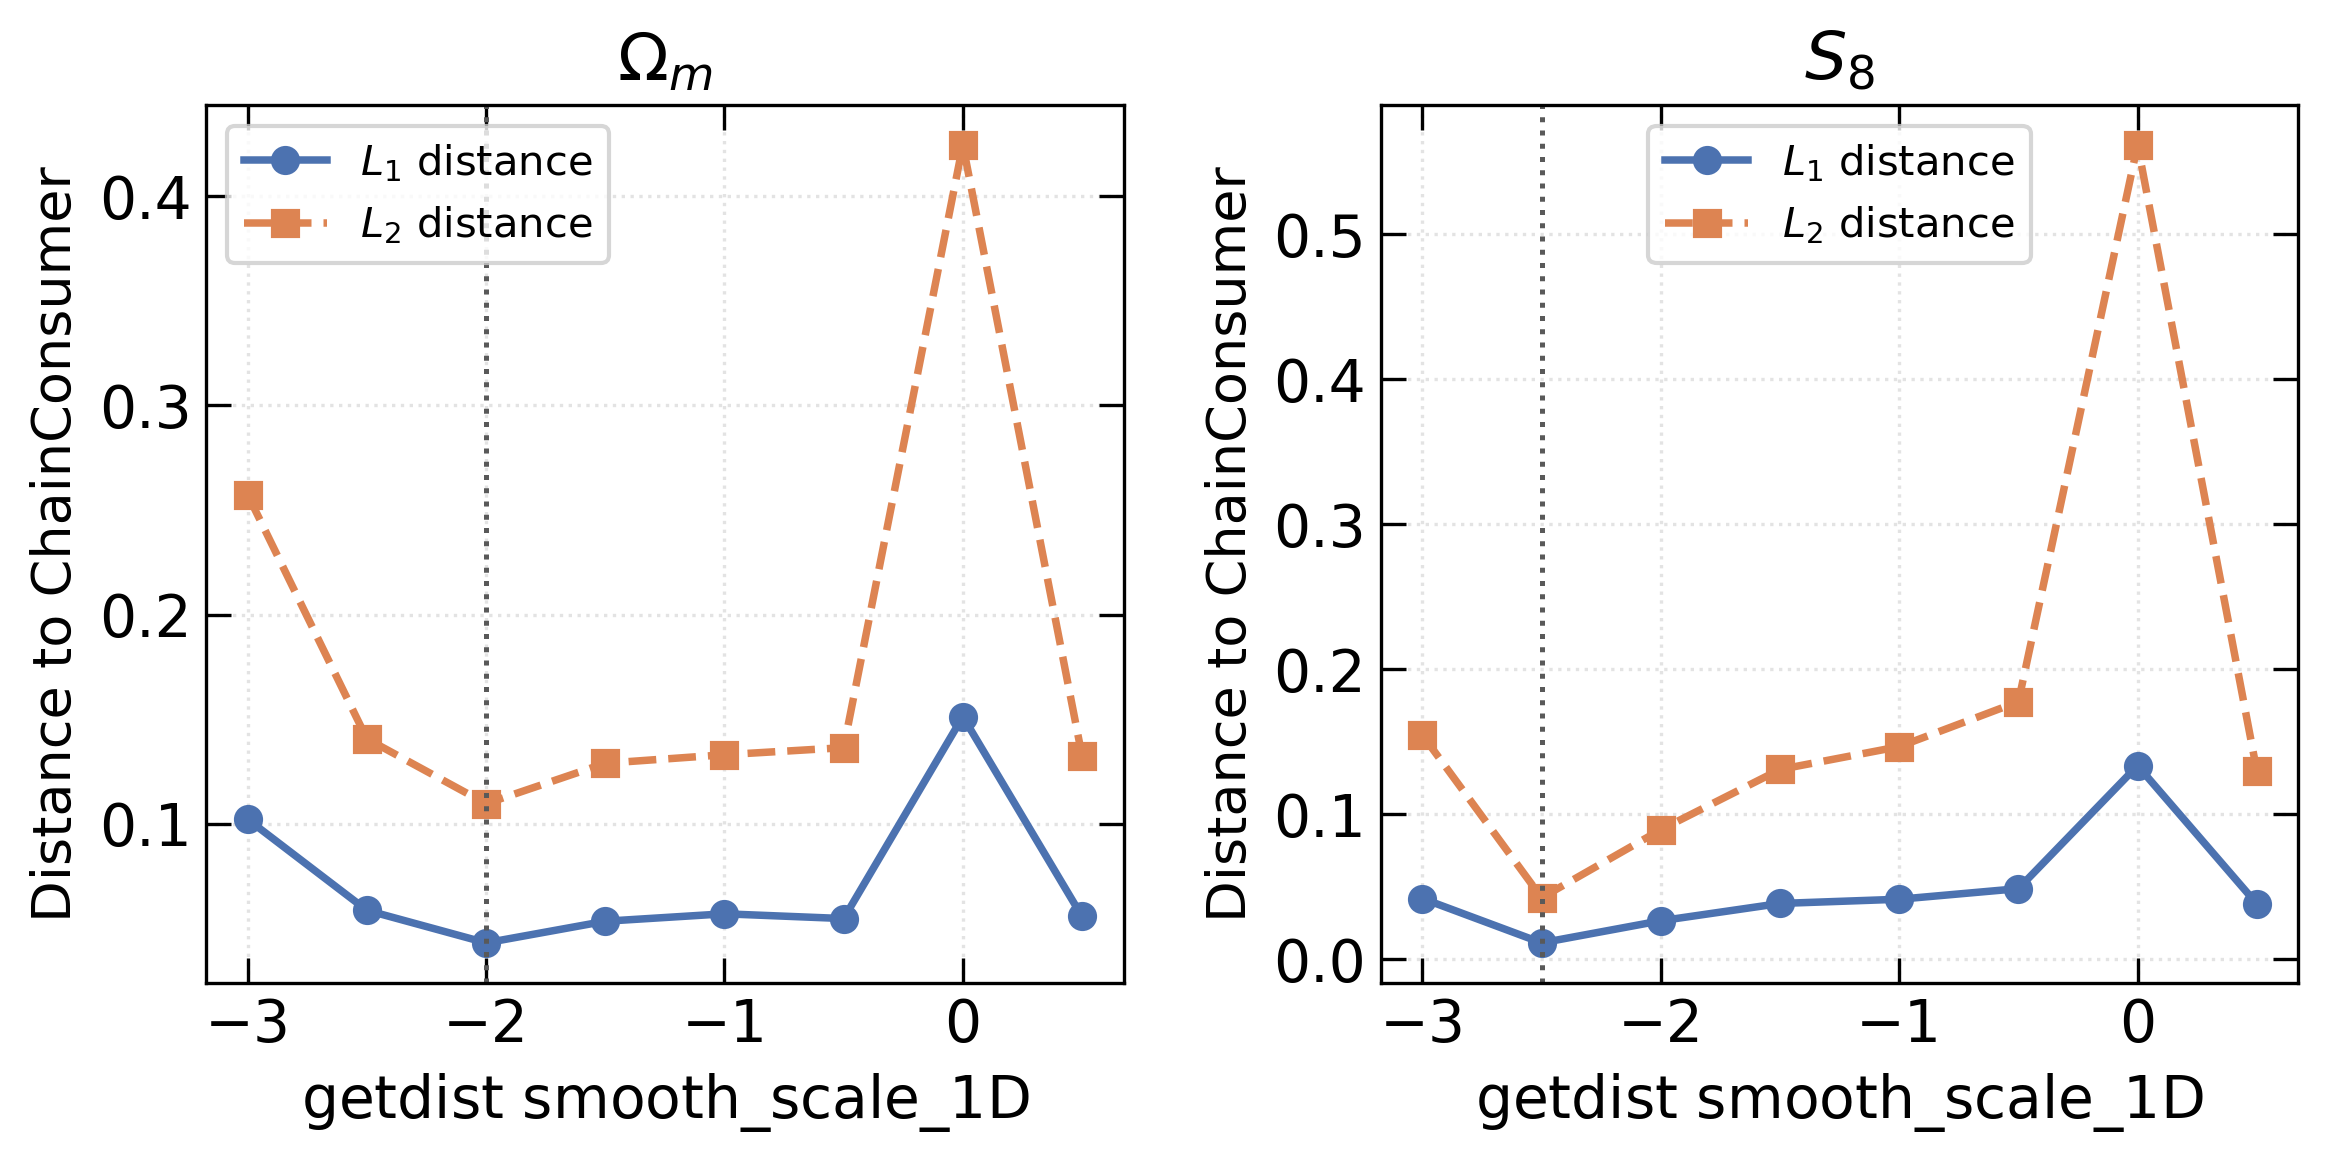

In [74]:
scan_params = [
    "cosmological_parameters--omega_m",
    "COSMOLOGICAL_PARAMETERS--S_8",
]
scan_scales = np.arange(-3.0, 1, 0.5)


def compare_getdist_smoothing(
    param: str,
    smooth_scales: np.ndarray,
) -> pd.DataFrame:
    """Compare getdist 1D densities with ChainConsumer on a common grid."""
    cc_x, cc_pdf = extract_chainconsumer_density(consumer, cc_param_map[param])
    rows = []

    for scale in smooth_scales:
        density = getdist_samples.get1DDensity(
            param,
            smooth_scale_1D=float(scale),
            boundary_correction_order=1,
            mult_bias_correction_order=1,
            fine_bins=getdist_samples.fine_bins,
        )
        gd_x, gd_pdf = normalize_density(
            np.asarray(density.x, dtype=float),
            np.asarray(density.P, dtype=float),
        )
        cc_pdf_on_gd = np.interp(gd_x, cc_x, cc_pdf)
        delta = gd_pdf - cc_pdf_on_gd

        rows.append(
            {
                "parameter": label_map[param],
                "param_key": param,
                "smooth_scale_1D": float(scale),
                "l1_distance": np.trapezoid(np.abs(delta), gd_x),
                "l2_distance": np.sqrt(np.trapezoid(delta**2, gd_x)),
                "max_abs_delta": np.max(np.abs(delta)),
            }
        )

    return pd.DataFrame(rows).sort_values("smooth_scale_1D").reset_index(drop=True)


scan_df = pd.concat(
    [compare_getdist_smoothing(param, scan_scales) for param in scan_params],
    ignore_index=True,
)
best_scan_df = (
    scan_df.sort_values(["param_key", "l1_distance"])
    .groupby("param_key", as_index=False)
    .first()
    [["parameter", "smooth_scale_1D", "l1_distance", "l2_distance", "max_abs_delta"]]
    .rename(columns={"smooth_scale_1D": "best_smooth_scale_1D"})
)

scan_file = SUMMARY_ROOT / "chainconsumer_getdist_smoothing_scan_0p3_3.txt"
with open(scan_file, "w") as stream:
    stream.write("Best getdist smoothing by L1 distance to ChainConsumer\n\n")
    stream.write(best_scan_df.to_string(index=False))
    stream.write("\n\nFull scan\n\n")
    stream.write(scan_df.to_string(index=False))

print(f"Saved smoothing scan to {scan_file}")
best_scan_df

with pm.make_plot(
    figsize=(PDF_PANEL_WIDTH * len(scan_params), PDF_PANEL_HEIGHT),
    name="getdist_chainconsumer_smoothing_scan_0p3_3.png",
    nrows=1,
    ncols=len(scan_params),
    sharey=False,
    show=True,
    tight_layout=False,
) as (fig, axes):
    axes = np.atleast_1d(axes)
    for axis, param in zip(axes, scan_params):
        current = scan_df[scan_df["param_key"] == param].sort_values("smooth_scale_1D")
        best_row = current.loc[current["l1_distance"].idxmin()]

        axis.plot(
            current["smooth_scale_1D"],
            current["l1_distance"],
            marker="o",
            color="#4c72b0",
            lw=1.8,
            label=r"$L_1$ distance",
        )
        axis.plot(
            current["smooth_scale_1D"],
            current["l2_distance"],
            marker="s",
            color="#dd8452",
            lw=1.8,
            ls="--",
            label=r"$L_2$ distance",
        )
        axis.axvline(best_row["smooth_scale_1D"], color="0.35", lw=1.2, ls=":")
        axis.set_xlabel(r"getdist $\mathrm{smooth\_scale\_1D}$", fontsize=14)
        axis.set_ylabel("Distance to ChainConsumer", fontsize=13)
        axis.set_title(label_map[param], fontsize=16)
        axis.grid(True, linestyle=":", alpha=0.35)
        axis.legend(loc="best", fontsize=10)

    plt.subplots_adjust(wspace=0.28)
    plt.show()